### This notebook compute "VCA15. Percentage of critical points on riverbanks or streams protected from danger" indicator for the 27 basins of IKI Project

Spanish: Porcentaje de puntos críticos en riberas de río o quebradas protegidas ante el peligro

**Created:** 10/10/2025 by Serena Gilson (sgilson@rti.org)  
**Project #:** 0219481  
**Last modified:**
**Status:** Complete and loaded in SQLite. 
**QA Status:** reviewed by  
**Original Script Stored at:** Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\Vulnerabilidad
 
**Inputs:**   Shapefile of COMIDs and districts, Puntos Criticos from ANA

**Outputs:** 
 
**Assumptions:** Given available information, calculation only includes the number of puntos criticos from ANA per area of COMID, not the number of puntos criticos 'atendidos' (from local government, etc.) as detailed in the annex. 
 
**Future work:** Normalize. 
 
**Notes:** 

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import sqlite3
import matplotlib.pyplot as plt

In [ ]:
#SETTINGS

#user = 'jmayo'
#user= 'cpickering'
user = 'sgilson'
ScnID= 1 #Climate Scenario ID -- 1: Baseline, 1981-2005, 2: Future, 2030, 3: Future: 2050
IndID= 515 #Indicator ID (Exposure = 2 + 0X where X is the Exposure Indicator number, Peligro= 1 +0x, VSB= 3 +0x, VSS= 4 +0x, VCA= 5 +0x)
db_path = fr'C:\Users\{user}\Research Triangle Institute\IKI Peru Project - General\Interno\AI2a_Metodologia\Indicadores\BD_RiesgoClimatico_IKI.db'

In [ ]:
#INPUTS

subbasins_shapefile = f'C:/Users/{user}/Research Triangle Institute/IKI Peru Project - General/Interno/AI2b_Modelacion/Grupos_Modelacion/GIS_WaterALLOC_General/Peru_AHD_with_districts.shp'
subbasins_gdf = gpd.read_file(subbasins_shapefile).to_crs('EPSG:32718')

#read in shapefiles 

#read in puntos criticos
pc_shp = f'C:\\Users\\{user}\\Research Triangle Institute\\IKI Peru Project - General\\Interno\\GIS\\3_HIDROLOGIA_HYDROGRAPHY\\Datos_ANA\\PuntosCriticos\\PuntosCriticos.shp'
pc_gdf = gpd.read_file(pc_shp).to_crs(subbasins_gdf.crs)



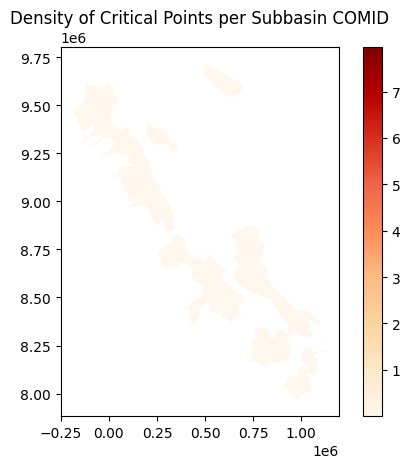

In [ ]:
#CALCULATION OF INDICATOR VALUE TO FIND DENSITY OF FEATURES PER 250 KM2

#count number of points in each subbasin COMID and divide by area of the COMID
subbasins_pc = gpd.sjoin(subbasins_gdf, pc_gdf, how='left', predicate='contains')
subbasins_pc_count = subbasins_pc.groupby('COMID').size().reset_index(name='PC_Count')
subbasins_pc_count = subbasins_pc_count.merge(subbasins_gdf[['COMID']], on='COMID', how='left')
#merge back to subbasins_gdf
subbasins_pc_gdf = subbasins_gdf.merge(subbasins_pc_count[['COMID', 'PC_Count']], on='COMID', how='left')
#calculate Area in km2 to confirm value in AREASQKM 
subbasins_pc_gdf['Area_km2'] = subbasins_pc_gdf.geometry.to_crs(epsg=6933).area / 10**6
#calculate density of critical points per km2
subbasins_pc_gdf['PC_Density'] = subbasins_pc_gdf['PC_Count'] / subbasins_pc_gdf['Area_km2']
#fill NaN with 0
subbasins_pc_gdf['PC_Density'] = subbasins_pc_gdf['PC_Density'].fillna(0)



In [ ]:
#PLOT AND QC 

#plot to check
subbasins_pc_gdf.plot(column='PC_Density', cmap='OrRd', legend=True)
plt.title('Density of Critical Points per Subbasin COMID')
plt.show()

subbasins_pc_gdf.describe()

#histogram of value above, excluding zeros
subbasins_pc_gdf['PC_Density'][subbasins_pc_gdf['PC_Density'] > 0].hist(bins=30)

#visual summary table, excluding zeros
subbasins_pc_gdf['PC_Density'][subbasins_pc_gdf['PC_Density'] > 0].describe()

,COMID,GRID_CODE,GRID_COUNT,AREASQKM,grupo_mod,PC_Count,Area_km2,PC_Density
count,3.655000e+03,3.655000e+03,3655.000000,3655.000000,3655.000000,3655.000000,3655.000000,3655.000000
mean,3.085487e+08,3.085465e+08,448.222435,93.963552,6.398085,1.747469,93.963555,0.071048
std,2.145454e+06,2.139460e+06,358.993004,75.263831,3.207296,2.993146,75.263824,0.286102
min,3.042739e+08,3.042287e+08,1.000000,0.208000,1.000000,1.000000,0.208314,0.001274
25%,3.066237e+08,3.066304e+08,231.500000,48.417000,3.000000,1.000000,48.416718,0.008956
50%,3.091100e+08,3.091157e+08,369.000000,77.557000,6.000000,1.000000,77.557234,0.014812
75%,3.102598e+08,3.102610e+08,599.000000,125.278000,10.000000,1.000000,125.278277,0.033976
max,3.202546e+08,3.192328e+08,3997.000000,859.983000,12.000000,57.000000,859.982512,7.970655


SQLITE INSERT 

In [11]:
#Update relevant dataframe and value column from the calculations above for the specific indicator
insert_data= subbasins_pc_gdf #COMID 
value_column= 'PC_Density'

In [12]:
# Connect to your SQLite database
conn = sqlite3.connect(db_path)
cursor = conn.cursor()

# Fixed IndID and ScnID (update above)

#For now I am commenting out the looping of scenarios as I imagine we might run just baseline scenarios for now.
# Define the mapping between scenario and DataFrame column
# scenario_columns = {
#     1: 'ACTUAL ANUAL',
#     2: '2030 ANUAL',
#     3: '2050 ANUAL'
# }

# Prepare list of rows to insert
rows_to_insert = []

#for scn_id, column_name in scenario_columns.items():
for _, row in insert_data.iterrows():
    comid = row['COMID']
    value = row[value_column]
    #normalized_value = None  # or compute something like: value / max_value #took out normalized value from the table for now
    rows_to_insert.append((ScnID, IndID, comid, value))

# Insert data into IndValues_Dyn
insert_query = """
INSERT OR REPLACE INTO IndValues_Dyn (ScnID, IndID, COMID, Value)
VALUES (?, ?, ?, ?);
"""


In [13]:
# Check for duplicates in the input dataframe before insert
df_check = pd.DataFrame(rows_to_insert, columns=['ScnID', 'IndID', 'COMID', 'Value'])
duplicates = df_check.duplicated(subset=['ScnID', 'IndID', 'COMID'])
print("Duplicates in rows_to_insert:", df_check[duplicates])

Duplicates in rows_to_insert: Empty DataFrame
Columns: [ScnID, IndID, COMID, Value]
Index: []


In [14]:
rows_to_insert

[(1, 515, 311153600, 0.007841329803955608),
 (1, 515, 310832400, 0.021090622268749755),
 (1, 515, 310825700, 0.014907921644572927),
 (1, 515, 310282400, 0.0073196379760496234),
 (1, 515, 308754600, 0.008182743310850234),
 (1, 515, 307736500, 0.33309564770001343),
 (1, 515, 307078200, 0.010926219344771906),
 (1, 515, 307183500, 0.006032542905396205),
 (1, 515, 306538400, 0.007347260131691258),
 (1, 515, 306599700, 0.016189568224602227),
 (1, 515, 306319300, 0.004651257372343093),
 (1, 515, 306030000, 0.0060497442299811905),
 (1, 515, 305746400, 0.015472707322598147),
 (1, 515, 311953100, 0.04081864988681342),
 (1, 515, 304273900, 0.005222322909308255),
 (1, 515, 304281100, 0.009131634493157573),
 (1, 515, 304281200, 0.008922948390521237),
 (1, 515, 304379300, 0.004183228916593299),
 (1, 515, 304274000, 0.01761167731984477),
 (1, 515, 304313700, 0.010433901609321035),
 (1, 515, 304306400, 0.02646824229805644),
 (1, 515, 304327700, 0.006712148772130901),
 (1, 515, 304313800, 0.01168309754

In [15]:
#Execute insert to SQLite Database
cursor.executemany(insert_query, rows_to_insert)
conn.commit()
conn.close()